In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt


Setting up the data set which we want to learn.



In [ ]:
datadim= 5 # intrinsic dimension of data
dim= 500 # dimension of the ambient space
N= 5000 # data set size
eps = 0.0 # noise level in the observed data

# create a low-dimensional data set
Xreal = torch.normal(mean =0, std=1.0, size=[N,datadim])

# compute the target function
Y = torch.tanh(Xreal[:,0])

# a matrix to embed the given data into a high-dimensional ambient space
transform = torch.normal(mean =0, std=1.0, size=[datadim,dim])

# the high-dimensional data is obtained by matrix multiplication
X = torch.matmul(Xreal, transform)

# making the observations noisy
X += torch.normal (mean =0, std=eps, size = X.shape )
Y += torch.normal (mean =0, std=eps, size = Y.shape )

# Note: If you generate a dataset in numpy and then convert it to torch tensors, you may run into trouble with default data types.
# The default for torch is float32.

We now convert the data set which we just created into a PyTorch Dataset structure.


In [ ]:
# We further convert the tensor into a dataset. This data structure will make our lives easier.
# Many standard data sets like MNIST and CIFAR-10 are automatically available as PyTorch Datasets.
Data= torch.utils.data.TensorDataset(X,Y)

# We define how to load data from the set for SGD optimization
batch_size=20
# Random pass
trainloader = torch.utils.data.DataLoader(Data, batch_size=batch_size, shuffle=True)

We now build a simple neural network model

In [ ]:
width = 30
depth = 3

class ffn(nn.Module):
  def __init__(self):
    super(ffn, self).__init__()

    self.layers = nn.ModuleList([nn.Linear(dim,width)])
    self.layers.extend([nn.Linear(width,width) for i in range(1,depth-1)])
    self.layers.extend([nn.Linear(width,1)])
    # If we want, we can choose the initialization differently. The pytorch default initialization is not always optimal.
    #for l in range(depth):
    #  torch.nn.init.xavier_uniform_(self.layers[l].weight, gain =np.sqrt(2.0))

  def forward(self, x):
    for i in range(depth-1):
      x=F.relu(self.layers[i](x))
    x = self.layers[depth-1](x)
    return x

# run everything on a gpu if available
# note: this works generally on nvidia gpus. The GPUs on M1 macbooks require a different syntax

device = "cuda" if torch.cuda.is_available() else "cpu"
model = ffn().to(device=device)

print(model)
print(torch.cuda.is_available())

ffn(
  (layers): ModuleList(
    (0): Linear(in_features=500, out_features=30, bias=True)
    (1): Linear(in_features=30, out_features=30, bias=True)
    (2): Linear(in_features=30, out_features=1, bias=True)
  )
)
False


It remains to train the neural network. We fix the associated hyperparameters.

In [ ]:
loss_function = nn.MSELoss() #MSE = mean squared error = L2 distance
optimizer = torch.optim.SGD(model.parameters(), lr =1e-3)

no_of_epochs = 25 #This is how often we iterate through the entire data set

Now we train!

During epoch 0, the average loss was 0.47544193163514137
During epoch 1, the average loss was 0.10518855371326208
During epoch 2, the average loss was 0.07242979311943054
During epoch 3, the average loss was 0.06038010715693235
During epoch 4, the average loss was 0.052025637965649366
During epoch 5, the average loss was 0.0461340634226799
During epoch 6, the average loss was 0.042626079726964236
During epoch 7, the average loss was 0.03851924549788237
During epoch 8, the average loss was 0.03607374891266227
During epoch 9, the average loss was 0.03302295844629407
During epoch 10, the average loss was 0.03125113686919213
During epoch 11, the average loss was 0.028953573901206255
During epoch 12, the average loss was 0.027436716821044684
During epoch 13, the average loss was 0.026203695913776755
During epoch 14, the average loss was 0.024709133910015224
During epoch 15, the average loss was 0.024125960621982814
During epoch 16, the average loss was 0.022164550393819808
During epoch 17, 

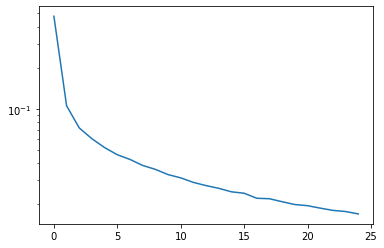

In [ ]:
# We put our model in training mode. That is not important for us right now, but best practice.
# It becomes really important if we have advanced layers which behave differently during training and application
# Examples are dropout and batch normalization.
model.train()
losses= []

for epoch in range(no_of_epochs):
  average_loss = 0.0 # we'll estimate an average of how high the loss is over the epoch
  for data, labels in trainloader:
    # send the data to the GPU (if available)
    # there is not enough space to keep the whole data set there permanently
    data = data.to(device)
    labels = labels.to(device)

    # In PyTorch, we have to manually set the gradient to zero during training.
    # This is specific to PyTorch and not found like this in Tensorflow.
    optimizer.zero_grad()

    outputs = model(data)
    # The output of our neural network has shape [batch_size,1] instead of [batch_size]. Squeezing removes the superfluous dimension
    outputs = torch.squeeze(outputs)
    loss = loss_function(outputs, labels)

    # Compute the gradient of the loss function
    # The naming refers to the fact that gradients of a neural network are computed by the back-propagation algorithm.
    loss.backward()
    # Take a time-step
    optimizer.step()

    # We add the loss we observed. The .item() allows us to just take the value of the loss - a real number - instead of the tensor object that is loss.
    average_loss += loss.item()
  #At the end of the epoch, we see how well we did.
  print("During epoch {}, the average loss was {}".format(epoch, average_loss / len(trainloader)))
  losses.append(average_loss / len(trainloader))

plt.semilogy(losses)

#torch.save(model.state_dict(), 'model_weights.pth')
#device = "cuda" if torch.cuda.is_available() else "cpu"
#model = ffn().to(device=device)
#model.load_state_dict(torch.load('model_weights.pth'))

To assess how well we did, we generate a data set from the same distribution and test our model on that.

In [ ]:
Ntest = 500
Xrealtest = torch.normal(mean =0, std=1.0, size=[N,datadim])
Ytest = torch.tanh(Xrealtest[:,0])
Xtest = torch.matmul(Xrealtest, transform) # note that we use the same embedding into the high-dimensional space

TestData= torch.utils.data.TensorDataset(Xtest,Ytest)
test_batch_size=100
testloader = torch.utils.data.DataLoader(TestData, batch_size=batch_size)

# We put the model into evaluation mode for deployment and/or testing on unseen data
model.eval()
testloss= 0.0

for data, labels in testloader:
    data = data.to(device)
    labels = labels.to(device)

    outputs = torch.squeeze(model(data))
    loss = loss_function(outputs, labels)

    testloss += loss.item()

testloss /= len(testloader)

print(testloss)


0.02083610509335995
